# 1.환경 준비

- 데이터 : cars.csv
- 단순 선형 회귀 모델을 만들고 평가한다.
- 회귀 계수를 명확히 이해한다.

In [2]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [5]:
# cars.csv
path = './../00_data/cars.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [6]:
df.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


In [7]:
df.tail()

,speed,dist
45,24,70
46,24,92
47,24,93
48,24,120
49,25,85


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


In [9]:
df.describe()

,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


In [10]:
df.isna().sum()

speed    0
dist     0
dtype: int64

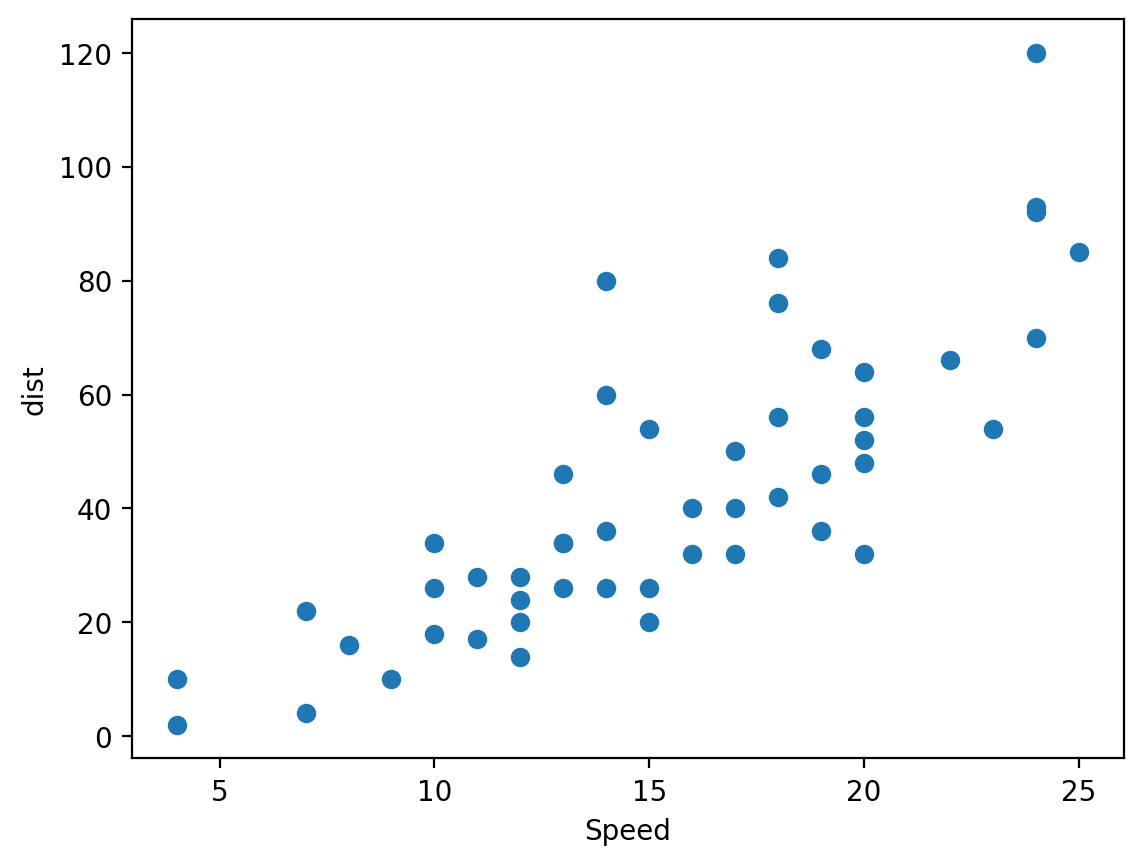

In [11]:
plt.scatter(x='speed', y='dist', data=df)

plt.xlabel('Speed')
plt.ylabel('dist')
plt.show()

# 3.데이터 전처리

**1) x, y 분리**

In [15]:
target = 'dist'
X = df.drop(target, axis=1)
y = df[target]

**2) 학습용, 평가용 데이터 분리**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=2026)

# 4.모델링


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)

In [22]:
print('MAE : ', mean_absolute_error(y_test, y_pred))
print('r2 : ', r2_score(y_test, y_pred))

MAE :  12.101828348600227
r2 :  0.5640271559993144


- 회귀 계수

In [ ]:
print(model.coef_) # 가중치(기울기)
print(model.intercept_) # 편향, (y 절편)

[4.05214656]


$$\large Distance = 3.19\times Speed-16.37  $$

# 5.기타

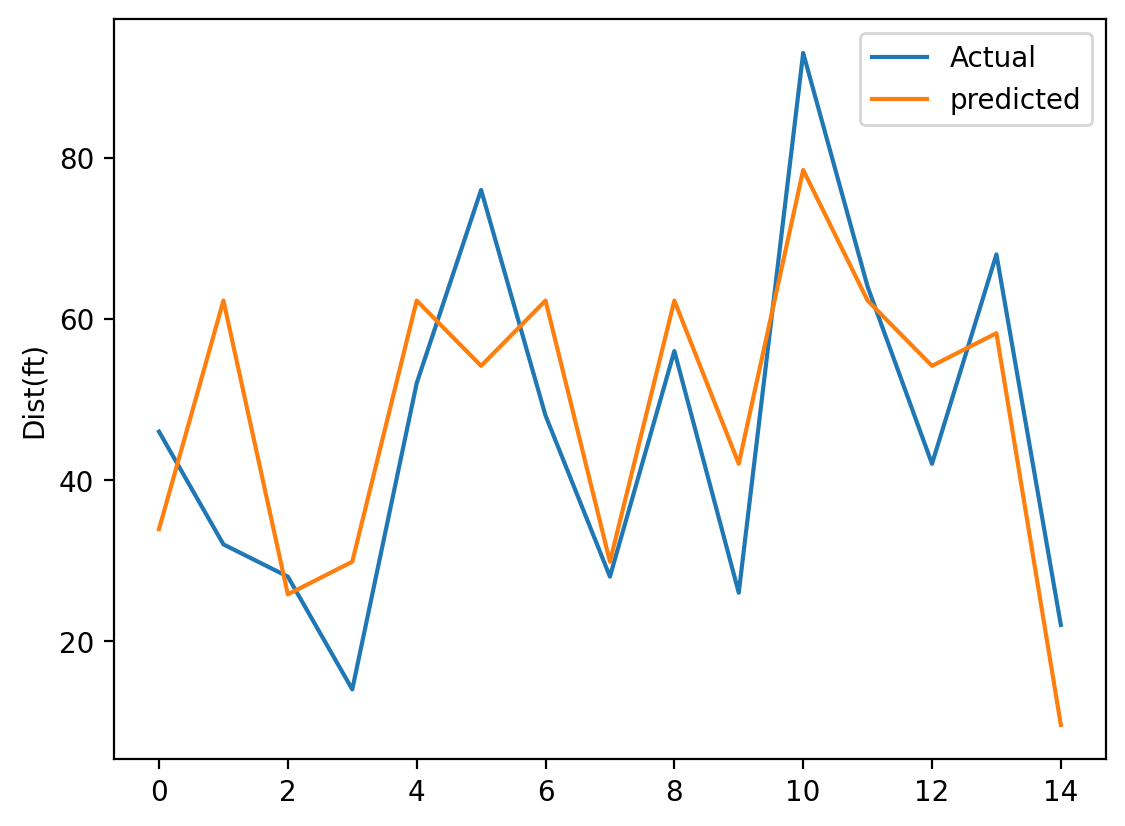

In [24]:
# 시각화
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='predicted')
plt.legend()
plt.ylabel('Dist(ft)')
plt.show()

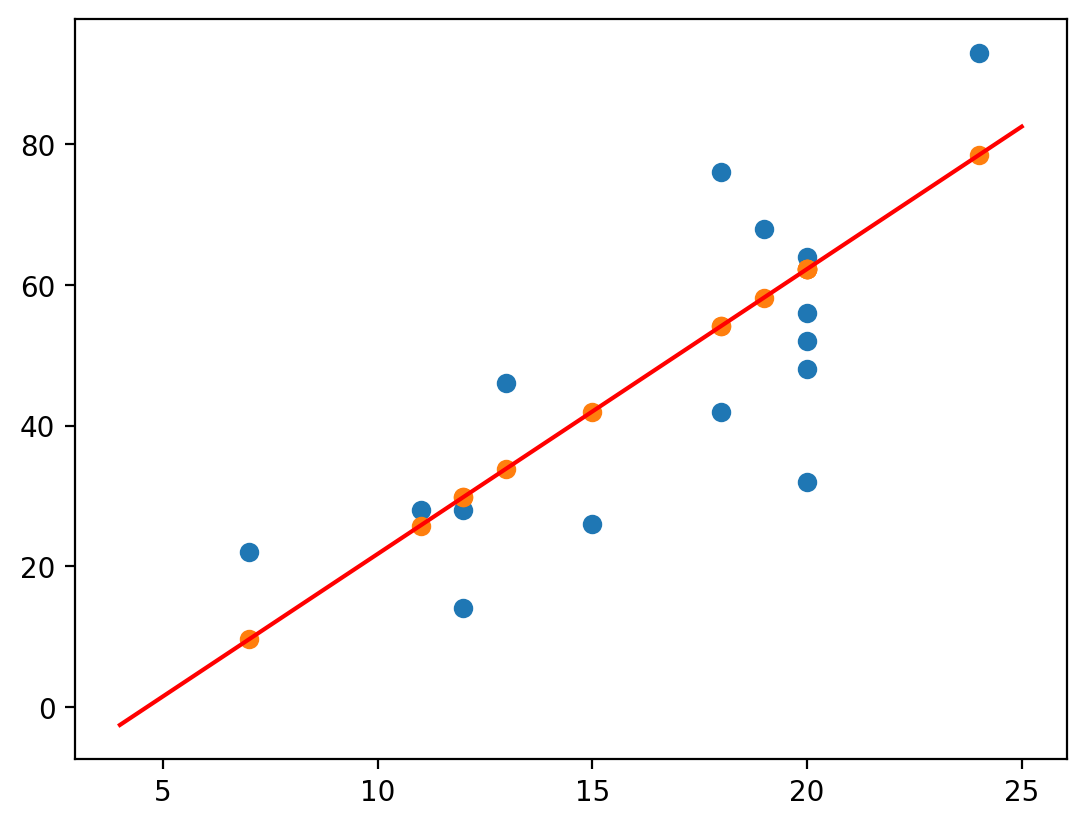

In [25]:
a = model.coef_ # 기울기 (가중치)

b = model.intercept_ # 절편(상수항)

# 회귀선(직선)을 그리기 위한 x 구간 (최솟값~최댓값)
speed = np.array([X_train.min(), X_train.max()])

dist = a * speed + b
plt.scatter(X_test, y_test) # 실제값
plt.scatter(X_test, y_pred) # 예측값
plt.plot(speed, dist, color='r') # 회귀선 - 빨간 직선으로 모델의 예측 패턴 표시
plt.show()